In [15]:
import pandas as pd
import numpy as np

In [16]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

In [17]:
!wget $data

--2026-10-05 19:20:52--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.3’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.007s  

2026-10-05 19:20:52 (81.5 MB/s) - ‘car_fuel_efficiency_2026.csv.3’ saved [635180/635180]



In [21]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [22]:
df = df[['engine_displacement',
         'horsepower',
         'vehicle_weight',
         'model_year',
         'fuel_efficiency_mpg']]

In [23]:
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


<Axes: >

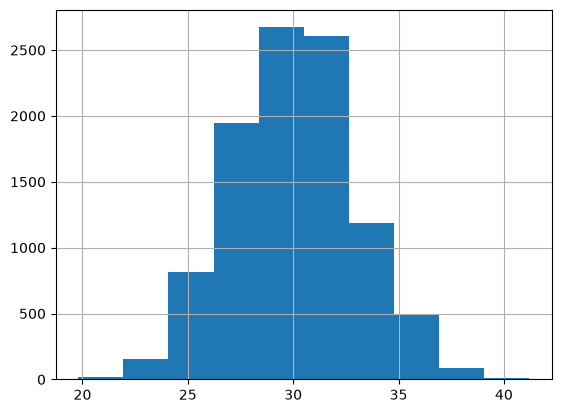

In [24]:
df['fuel_efficiency_mpg'].hist()

In [25]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [26]:
df['horsepower'].median()

np.float64(254.0)

In [27]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)

idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [28]:
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values

In [29]:
X_train = df_train.drop('fuel_efficiency_mpg', axis=1)
X_val = df_val.drop('fuel_efficiency_mpg', axis=1)

In [30]:
X_train_zero = X_train.fillna(0).values
X_val_zero = X_val.fillna(0).values

In [31]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [32]:
def rmse(y, y_pred):
    error = y - y_pred
    return np.sqrt((error ** 2).mean())

In [33]:
w0, w = train_linear_regression(X_train_zero, y_train)
y_pred = w0 + X_val_zero.dot(w)

round(rmse(y_val, y_pred), 3)

np.float64(2.205)

In [34]:
mean = X_train['horsepower'].mean()

X_train_mean = X_train.fillna(mean).values
X_val_mean = X_val.fillna(mean).values

w0, w = train_linear_regression(X_train_mean, y_train)
y_pred = w0 + X_val_mean.dot(w)

round(rmse(y_val, y_pred), 3)

np.float64(2.202)

In [35]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [36]:
X_train = df_train.drop('fuel_efficiency_mpg', axis=1).fillna(0).values
X_val = df_val.drop('fuel_efficiency_mpg', axis=1).fillna(0).values

In [37]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r)
    y_pred = w0 + X_val.dot(w)
    
    print(r, round(rmse(y_val, y_pred), 4))

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


In [38]:
scores = []

for seed in range(10):
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]

    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values

    X_train = df_train.drop('fuel_efficiency_mpg', axis=1).fillna(0).values
    X_val = df_val.drop('fuel_efficiency_mpg', axis=1).fillna(0).values

    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)
    scores.append(score)

In [39]:
scores

[np.float64(2.2392041430461465),
 np.float64(2.2021128210838907),
 np.float64(2.163419778753095),
 np.float64(2.2043588768539144),
 np.float64(2.2018800943312926),
 np.float64(2.2457851509084974),
 np.float64(2.269721207952404),
 np.float64(2.190794599933433),
 np.float64(2.2166112016864443),
 np.float64(2.207036592817851)]

In [40]:
round(np.std(scores), 3)

np.float64(0.029)

In [41]:
np.random.seed(9)

idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [42]:
df_train_full = pd.concat([df_train, df_val])

In [43]:
y_train = df_train_full['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

In [44]:
X_train = df_train_full.drop('fuel_efficiency_mpg', axis=1).fillna(0).values
X_test = df_test.drop('fuel_efficiency_mpg', axis=1).fillna(0).values

In [45]:
w0, w = train_linear_regression_reg(X_train, y_train, 0.001)

y_pred = w0 + X_test.dot(w)

rmse(y_test, y_pred)

np.float64(2.2358277471917636)